<a href="https://colab.research.google.com/github/AIML-Dept/RithikaRajavel_1GA23AI041/blob/main/WEEK_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial 7: Deutsch's Algorithm

Deutsch's Algorithm determines whether a one-bit Boolean function is
**constant** or **balanced** using only one quantum oracle query.

- Constant: f(0) = f(1)
- Balanced: f(0) ≠ f(1)

The four possible functions are f(x)=0, f(x)=1, f(x)=x, and f(x)=1-x.


In [2]:
!pip -q install qiskit qiskit-aer

import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

simulator = AerSimulator()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 76.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 2.6 MB/s eta 0:00:00


## 1. Deutsch's Algorithm

The circuit starts in |0>|1>. Hadamard gates create superposition,
the oracle encodes f(x), and the final Hadamard creates interference.

The measured result is:
- 0 → Constant
- 1 → Balanced


In [3]:
def deutsch_algorithm(function_type):

    qc = QuantumCircuit(2, 1)

    # Prepare |0>|1>
    qc.x(1)

    # Superposition
    qc.h(0)
    qc.h(1)

    # Oracle
    if function_type == "constant_0":
        pass

    elif function_type == "constant_1":
        qc.x(1)

    elif function_type == "balanced_x":
        qc.cx(0, 1)

    elif function_type == "balanced_not_x":
        qc.x(1)
        qc.cx(0, 1)

    else:
        raise ValueError("Invalid function type")

    # Interference
    qc.h(0)

    # Measurement
    qc.measure(0, 0)

    return qc


## 2. Testing the Four Functions

We test all possible one-bit Boolean functions. The algorithm should
return 0 for constant functions and 1 for balanced functions.


In [4]:
functions = [
    "constant_0",
    "constant_1",
    "balanced_x",
    "balanced_not_x"
]

results = {}

for f in functions:

    qc = deutsch_algorithm(f)

    result = simulator.run(
        transpile(qc, simulator),
        shots=1024
    ).result()

    counts = result.get_counts()
    output = max(counts, key=counts.get)

    results[f] = int(output)

    print(f"{f:20s} -> {counts}")


constant_0           -> {'0': 1024}
constant_1           -> {'0': 1024}
balanced_x           -> {'1': 1024}
balanced_not_x       -> {'1': 1024}


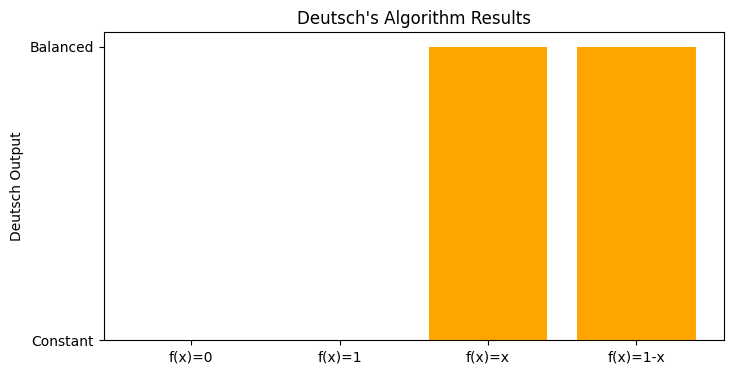

In [5]:
labels = ["f(x)=0", "f(x)=1", "f(x)=x", "f(x)=1-x"]
values = list(results.values())

colors = ["green" if v == 0 else "orange" for v in values]

plt.figure(figsize=(8, 4))
plt.bar(labels, values, color=colors)

plt.yticks([0, 1], ["Constant", "Balanced"])
plt.ylabel("Deutsch Output")
plt.title("Deutsch's Algorithm Results")

plt.show()


## 3. Circuit Visualization

The following circuit shows the implementation for the balanced
function f(x)=x.


In [6]:
qc = deutsch_algorithm("balanced_x")

print(qc.draw())


     ┌───┐          ┌───┐┌─┐
q_0: ┤ H ├───────■──┤ H ├┤M├
     ├───┤┌───┐┌─┴─┐└───┘└╥┘
q_1: ┤ X ├┤ H ├┤ X ├──────╫─
     └───┘└───┘└───┘      ║ 
c: 1/═════════════════════╩═
                          0 


## 4. Generic Oracle

A generic oracle allows us to select the Boolean function dynamically
instead of creating a separate circuit for each function.


In [11]:
def apply_oracle(qc, function_type):

    if function_type == "constant_0":
        pass

    elif function_type == "constant_1":
        qc.x(1)

    elif function_type == "balanced_x":
        qc.cx(0, 1)

    elif function_type == "balanced_not_x":
        qc.x(1)
        qc.cx(0, 1)

    else:
        raise ValueError("Invalid function type")


def generic_deutsch(function_type):

    qc = QuantumCircuit(2, 1)

    qc.x(1)
    qc.h(0)
    qc.h(1)

    apply_oracle(qc, function_type)

    qc.h(0)
    qc.measure(0, 0)

    return qc


## 5. Quantum Advantage

A deterministic classical algorithm may require two queries:

1. Evaluate f(0)
2. Evaluate f(1)

Deutsch's Algorithm requires only one quantum oracle query.


In [12]:
print("Classical deterministic queries : 2 (worst case)")
print("Quantum Deutsch queries         : 1")
print("Quantum advantage                : 2x fewer queries")


Classical deterministic queries : 2 (worst case)
Quantum Deutsch queries         : 1
Quantum advantage                : 2x fewer queries


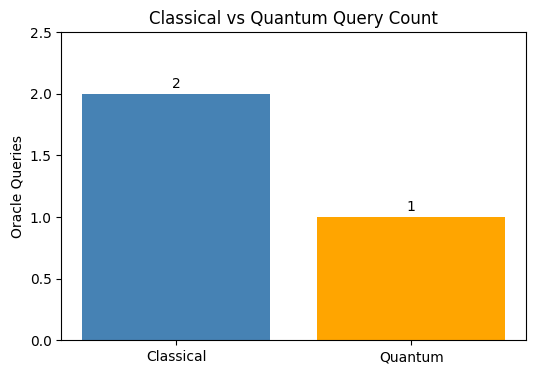

In [13]:
methods = ["Classical", "Quantum"]
queries = [2, 1]

plt.figure(figsize=(6, 4))
bars = plt.bar(methods, queries, color=["steelblue", "orange"])

plt.ylabel("Oracle Queries")
plt.title("Classical vs Quantum Query Count")

for bar, value in zip(bars, queries):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.05,
        str(value),
        ha="center"
    )

plt.ylim(0, 2.5)
plt.show()


## 6. Challenge: Imperfect Hadamard

Real quantum hardware contains noise and gate errors.

Here we replace the ideal Hadamard operation with a slightly imperfect
rotation. We then measure how often the correct answer is obtained.


In [14]:
def imperfect_deutsch(error):

    qc = QuantumCircuit(2, 1)

    # Prepare |0>|1>
    qc.x(1)

    # Imperfect H
    qc.ry(np.pi/2 + error, 0)
    qc.ry(np.pi/2 + error, 1)

    # Balanced oracle f(x)=x
    qc.cx(0, 1)

    # Final imperfect H
    qc.ry(np.pi/2 + error, 0)

    qc.measure(0, 0)

    return qc


The correct answer for f(x)=x is **1**. We calculate reliability as
the percentage of measurements that produce 1.


In [15]:
errors = [0, 0.05, 0.10, 0.20, 0.30, 0.50]
reliability = []

shots = 2000

for error in errors:

    qc = imperfect_deutsch(error)

    result = simulator.run(
        transpile(qc, simulator),
        shots=shots
    ).result()

    counts = result.get_counts()

    correct = counts.get("1", 0)
    reliability.append(correct / shots)

    print(
        f"Error = {error:.2f} rad | "
        f"Reliability = {correct/shots:.3f}"
    )


Error = 0.00 rad | Reliability = 0.000
Error = 0.05 rad | Reliability = 0.001
Error = 0.10 rad | Reliability = 0.004
Error = 0.20 rad | Reliability = 0.007
Error = 0.30 rad | Reliability = 0.021
Error = 0.50 rad | Reliability = 0.052


## 7. Gate Error vs Reliability

The graph shows how gate imperfections affect the reliability of the
quantum algorithm.


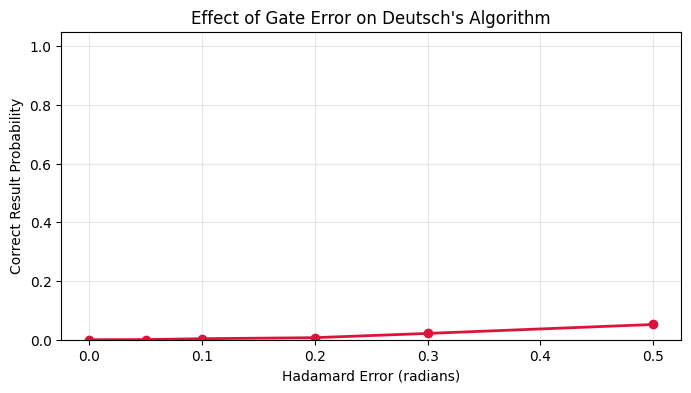

In [16]:
plt.figure(figsize=(8, 4))

plt.plot(
    errors,
    reliability,
    marker="o",
    linewidth=2,
    color="crimson"
)

plt.xlabel("Hadamard Error (radians)")
plt.ylabel("Correct Result Probability")
plt.title("Effect of Gate Error on Deutsch's Algorithm")

plt.ylim(0, 1.05)
plt.grid(alpha=0.3)

plt.show()


# Conclusion

Deutsch's Algorithm successfully distinguishes constant and balanced
functions using one quantum oracle query.

The experiment demonstrated:

- Constant functions give output 0.
- Balanced functions give output 1.
- Quantum computation uses one oracle query instead of two classical
  deterministic queries.
- Phase kickback and interference are key parts of the algorithm.
- Gate errors reduce measurement reliability.

## Reflection

**What did I learn?**

I learned how Deutsch's Algorithm uses superposition, phase kickback,
and interference to determine whether a Boolean function is constant
or balanced with a single quantum query.
